## EDA

In [109]:
import os
import typing
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from badwords import ProfanityFilter

In [110]:
# !pip install git+https://github.com/FlacSy/badwords.git

Немного пришечем данные: вынесем в отдельный столбец `mixed_class` флаг смешанного класса, `toxicity_class` строка-перечисление классов без префикса \_\_lable\_\_ через запятую, `message_text` - cам текст комментария.

In [111]:
def is_mixed_class(row: str) -> bool:
    sep_idx = row.index(" ")
    return len(row[:sep_idx].split(",")) > 1

def define_toxicity_class(row: str) -> str:
    sep_idx = row.index(" ")
    classes = row[:sep_idx].split(",")
    return ",".join([class_name[9:] for class_name in classes])

def extract_message_text(row: str) -> str:
    sep_idx = row.index(" ")
    return row[sep_idx + 1:]

In [112]:
lines = []
with open(os.path.expanduser("../dataset.txt"), "r") as file:
    lines = [line.rstrip() for line in file.readlines()]
data = pd.DataFrame(lines, columns=["raw_text"])
data["mixed_class"] = data["raw_text"].apply(is_mixed_class)
data["toxicity_class"] = data["raw_text"].apply(define_toxicity_class)
data["message_text"] = data["raw_text"].apply(extract_message_text)
data[["message_text", "toxicity_class", "mixed_class"]].describe()

,message_text,toxicity_class,mixed_class
count,248290,248290,248290
unique,248284,8,2
top,расстрелять нахуй,NORMAL,False
freq,2,203685,239957


In [113]:
data["mixed_class"].mean()

0.03356156107777196

Доля смешанных классов мала (всего 3%), поэтому в первом приближении можно пытаться решить задачу без них. Если потом появятся идеи как их можно использовать -- добавим обратно

In [114]:
clean_data = data[data["mixed_class"] == False][["message_text", "toxicity_class"]]
clean_data.drop_duplicates(subset=["message_text"], inplace=True)
clean_data["toxicity_class"].value_counts()

toxicity_class
NORMAL       203682
INSULT        28567
THREAT         5457
OBSCENITY      2245
Name: count, dtype: int64

Добавим примитивные численные признаки построенные по сообщению, чтобы оценить наличие выбросов по длине и составу символов.

In [115]:
clean_data["words"] = clean_data["message_text"].apply(lambda text: [word for word in text.split() if len(word) > 0])
clean_data["word_count"] = clean_data["words"].apply(lambda words: len(words))
clean_data["upper_case"] = clean_data["words"].apply(lambda words: any([word.isupper() for word in words]))
clean_data["symbol_count"] = clean_data["message_text"].apply(lambda text: sum([1 for symbol in text if not symbol.isspace()]))

In [116]:
for word in clean_data.iloc[0]['words']:
    print(word)
    pf = ProfanityFilter()
    pf.init(['ru'])
    print(pf.filter_text(word, match_threshold=0.5))

скотина!
True
что
True
сказать
True


In [117]:
mat = ['блять', "хуй", "пизда", "ебать"]

In [118]:
clean_data["swearing"] = clean_data["message_text"].apply(lambda text: sum([m in text for m in mat]) > 0)

In [126]:
clean_data["toxic"] = clean_data["toxicity_class"] != "NORMAL"

In [120]:
# clean_data["profanity"] = clean_data["message_text"].apply(lambda text: pf.filter_text(text, match_threshold=0.99))

In [121]:
# clean_data.loc[clean_data['swearing'] == True]

In [122]:
# clean_data.loc[clean_data['toxicity_class'].apply(len) > 6]

In [123]:
clean_data['symbol_count'].describe()

count    239951.000000
mean         66.483903
std          81.708431
min           2.000000
25%          23.000000
50%          40.000000
75%          74.000000
max         877.000000
Name: symbol_count, dtype: float64

In [129]:
clean_data[clean_data['symbol_count'] > clean_data['symbol_count'].quantile(0.999)]

,message_text,toxicity_class,words,word_count,upper_case,symbol_count,swearing,toxic
3647,согласна с вами!!! для ведьмы магия-образ жизн...,NORMAL,"[согласна, с, вами!!!, для, ведьмы, магия-обра...",143,False,795,False,False
4379,я юсупова римма хабибуллона глубоко возмутилас...,NORMAL,"[я, юсупова, римма, хабибуллона, глубоко, возм...",119,False,783,False,False
4424,московские волонтёры открыли сбор средств на б...,NORMAL,"[московские, волонтёры, открыли, сбор, средств...",113,False,758,False,False
4911,"⚡ вам не кажется, (! ?), что вы, в своих эмоци...",NORMAL,"[⚡, вам, не, кажется,, (!, ?),, что, вы,, в, с...",161,False,794,False,False
5672,"что-то я не понял, по 500 тысяч в месяц что ли...",NORMAL,"[что-то, я, не, понял,, по, 500, тысяч, в, мес...",140,False,828,False,False
...,...,...,...,...,...,...,...,...
245069,"вы не правы и вы это видимо поняли, раз удалил...",NORMAL,"[вы, не, правы, и, вы, это, видимо, поняли,, р...",182,False,790,False,False
245638,после неудачного обращения в районо ольга реши...,NORMAL,"[после, неудачного, обращения, в, районо, ольг...",141,False,789,False,False
245665,у каждого у нас свой счас дом. благодоря таким...,NORMAL,"[у, каждого, у, нас, свой, счас, дом., благодо...",164,False,826,True,False
246324,сегодня формируется новое информационное общес...,NORMAL,"[сегодня, формируется, новое, информационное, ...",94,False,755,False,False


In [132]:
import matplotlib.pyplot as plt

toxic_data = clean_data[clean_data['toxic'] == True]
non_toxic_data = clean_data[clean_data['toxic'] == False]

In [134]:
toxic_data.describe()

,word_count,symbol_count
count,36269.000000,36269.000000
mean,13.130332,69.055144
std,15.301217,79.499122
min,1.000000,4.000000
25%,5.000000,25.000000
50%,8.000000,43.000000
75%,15.000000,81.000000
max,171.000000,858.000000


In [135]:
non_toxic_data.describe()

,word_count,symbol_count
count,203682.000000,203682.000000
mean,12.345789,66.026050
std,15.508005,82.087343
min,1.000000,2.000000
25%,4.000000,23.000000
50%,7.000000,39.000000
75%,14.000000,73.000000
max,267.000000,877.000000


In [159]:
max_words_count = clean_data.word_count.max()

In [171]:
probs = {}
for i in range(1, max_words_count + 1, 5):
    toxic_true = len(clean_data[(clean_data['word_count'] == i) &  (clean_data['toxic'])])
    toxic_false = len(clean_data[(clean_data['word_count'] == i) &  (clean_data['toxic'] == False)])
    probs[i] = toxic_true / max(toxic_false, 1)

In [172]:
probs

{1: 0.14093549373280342,
 6: 0.16701421800947866,
 11: 0.1961632770806289,
 16: 0.2056451612903226,
 21: 0.22345483359746435,
 26: 0.20997586484312147,
 31: 0.20116279069767443,
 36: 0.21875,
 41: 0.20346320346320346,
 46: 0.16723549488054607,
 51: 0.1791044776119403,
 56: 0.17703349282296652,
 61: 0.1878453038674033,
 66: 0.16216216216216217,
 71: 0.15384615384615385,
 76: 0.20987654320987653,
 81: 0.15384615384615385,
 86: 0.2459016393442623,
 91: 0.1568627450980392,
 96: 0.17647058823529413,
 101: 0.2647058823529412,
 106: 0.2692307692307692,
 111: 0.17142857142857143,
 116: 0.04,
 121: 0.16666666666666666,
 126: 0.07692307692307693,
 131: 0.06666666666666667,
 136: 0.4166666666666667,
 141: 0.16666666666666666,
 146: 0.14285714285714285,
 151: 0.3333333333333333,
 156: 0.0,
 161: 0.0,
 166: 0.0,
 171: 0.5,
 176: 0.0,
 181: 0.0,
 186: 0.0,
 191: 0.0,
 196: 0.0,
 201: 0.0,
 206: 0.0,
 211: 0.0,
 216: 0.0,
 221: 0.0,
 226: 0.0,
 231: 0.0,
 236: 0.0,
 241: 0.0,
 246: 0.0,
 251: 0.0,
 2

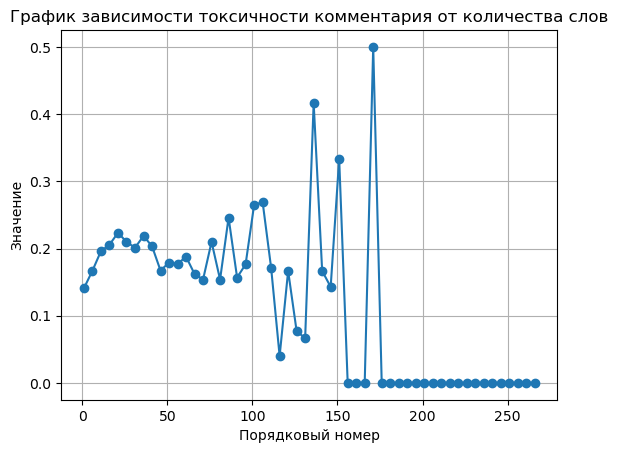

In [174]:
import matplotlib.pyplot as plt

# Ваш словарь с порядковыми номерами и значениями

# Извлекаем ключи и значения для осей X и Y
x = list(probs.keys())    # порядковые номера
y = list(probs.values())  # числовые значения

plt.plot(x, y, marker='o')  # Линейный график с точками

plt.xlabel('Порядковый номер')
plt.ylabel('Значение')
plt.title('График зависимости токсичности комментария от количества слов')
plt.grid(True)

plt.show()